## SMOTE for Customer Churn Prediction - Handling Class Imbalance

In [1]:
import warnings
warnings.filterwarnings("ignore")

# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, precision_recall_curve,
                           average_precision_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold
import joblib
import json

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


##  Load the dataset 

In [2]:
# Load the clean dataset saved 
df = pd.read_csv("data/cust_churn_data.csv")

cust_churn_data = df.copy()
print(f"Dataset shape: {cust_churn_data.shape}")
print("\nFirst 5 rows:")
cust_churn_data.head()

Dataset shape: (10000, 15)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40-49
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40-49
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-49
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-39
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40-49


## DATA PREPROCESSING

In [3]:
print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# Drop unnecessary columns
# RowNumber, CustomerId, and Surname are not useful for prediction
data_clean = cust_churn_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"After dropping irrelevant columns: {data_clean.shape}")

# Check class distribution
print("\nClass distribution (Exited column):")
class_dist = data_clean['Exited'].value_counts()
class_dist_percent = data_clean['Exited'].value_counts(normalize=True) * 100
print(f"Stayed (0): {class_dist[0]} ({class_dist_percent[0]:.2f}%)")
print(f"Churned (1): {class_dist[1]} ({class_dist_percent[1]:.2f}%)")

DATA PREPROCESSING
After dropping irrelevant columns: (10000, 12)

Class distribution (Exited column):
Stayed (0): 7963 (79.63%)
Churned (1): 2037 (20.37%)


<Figure size 1000x600 with 0 Axes>

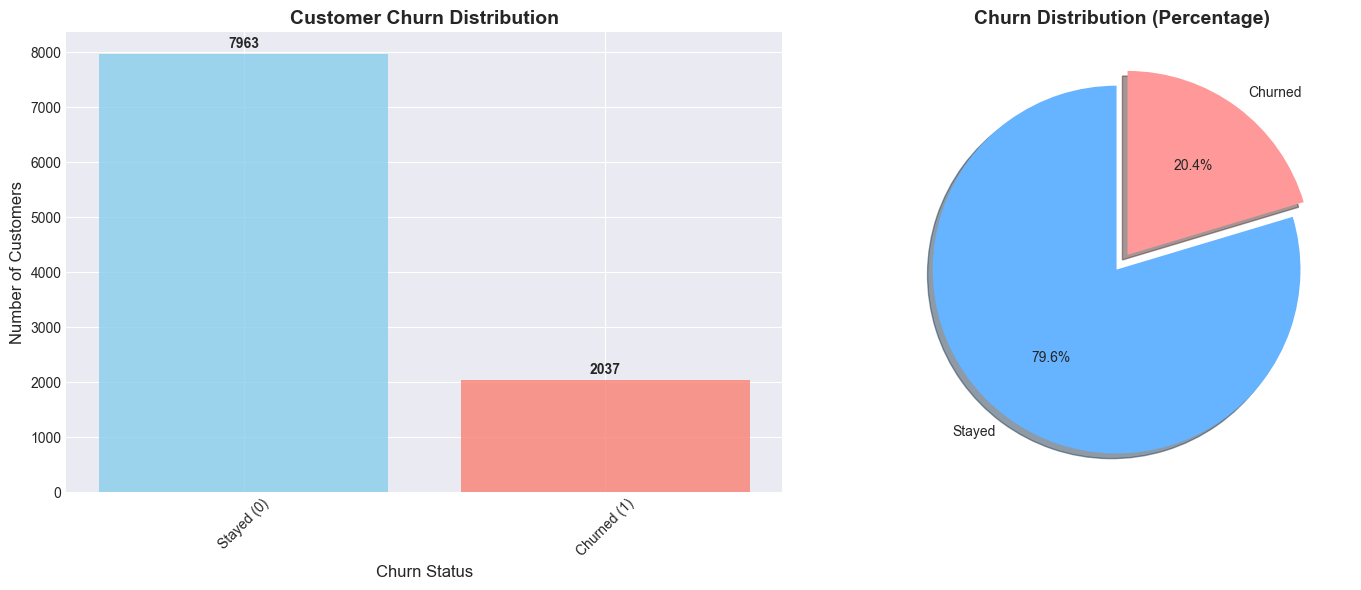

In [4]:
# visualize the class imbalance
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
bars = ax1.bar(['Stayed (0)', 'Churned (1)'], class_dist.values, 
               color=['skyblue', 'salmon'], alpha=0.8)
ax1.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add count labels on top of bars
for bar, count in zip(bars, class_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#66b3ff', '#ff9999']
ax2.pie(class_dist.values, labels=['Stayed', 'Churned'], 
        autopct='%1.1f%%', startangle=90, colors=colors,
        explode=(0.05, 0.05), shadow=True)
ax2.set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("saved_images/class_imbalance_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

## # ENCODING CATEGORICAL VARIABLES

In [4]:
print("=" * 70)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 70)

# Separate features and target
X = data_clean.drop('Exited', axis=1)
y = data_clean['Exited']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Create a copy for encoding
X_encoded = X.copy()

# Apply Label Encoding to categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nShape after encoding: {X_encoded.shape}")
print("\nFirst 5 rows of encoded data:")
X_encoded.head()

# SAVE THE LABEL ENCODERS FOR LATER USE IN PREDICTIONS
print("\n" + "=" * 70)
print("SAVING LABEL ENCODERS FOR FUTURE USE")
print("=" * 70)

# Create encoder_info dictionary with encoding mappings
encoder_info = {}
for col, le in label_encoders.items():
    encoder_info[col] = {
        'encoder': le,
        'mapping': dict(zip(le.classes_, le.transform(le.classes_))),
        'classes': le.classes_.tolist()
    }
    print(f"Saved encoder for '{col}': {encoder_info[col]['mapping']}")

# Also save the feature names for prediction
feature_names = X_encoded.columns.tolist()
print(f"\nFeature names for prediction: {feature_names}")

# Save to a file for later use
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save encoders and feature names
encoding_data = {
    'label_encoders': label_encoders,
    'encoder_info': encoder_info,
    'feature_names': feature_names,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols
}

joblib.dump(encoding_data, 'saved_models/encoding_data.pkl')
print("\n Encoding data saved to 'saved_models/encoding_data.pkl'")
print("This will be used for encoding new data during predictions.")

# # Return the encoded X and y for further processing
# return X_encoded, y, label_encoders, feature_names

ENCODING CATEGORICAL VARIABLES
Categorical columns: ['Geography', 'Gender', 'AgeGroup']
Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Encoded Geography: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Encoded Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded AgeGroup: {'30-39': np.int64(0), '40-49': np.int64(1), '50-59': np.int64(2), '60+': np.int64(3), '<30': np.int64(4)}

Shape after encoding: (10000, 11)

First 5 rows of encoded data:

SAVING LABEL ENCODERS FOR FUTURE USE
Saved encoder for 'Geography': {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Saved encoder for 'Gender': {'Female': np.int64(0), 'Male': np.int64(1)}
Saved encoder for 'AgeGroup': {'30-39': np.int64(0), '40-49': np.int64(1), '50-59': np.int64(2), '60+': np.int64(3), '<30': np.int64(4)}

Feature names for prediction: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Bala

In [6]:
# print("=" * 70)
# print("ENCODING CATEGORICAL VARIABLES")
# print("=" * 70)

# # Separate features and target
# X = data_clean.drop('Exited', axis=1)
# y = data_clean['Exited']

# # Identify categorical and numerical columns
# categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
# numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# print(f"Categorical columns: {categorical_cols}")
# print(f"Numerical columns: {numerical_cols}")

# # Create a copy for encoding
# X_encoded = X.copy()

# # Apply Label Encoding to categorical variables
# label_encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     X_encoded[col] = le.fit_transform(X[col])
#     label_encoders[col] = le
#     print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# print(f"\nShape after encoding: {X_encoded.shape}")
# print("\nFirst 5 rows of encoded data:")
# X_encoded.head()

FEATURE DISTRIBUTION BY CHURN STATUS


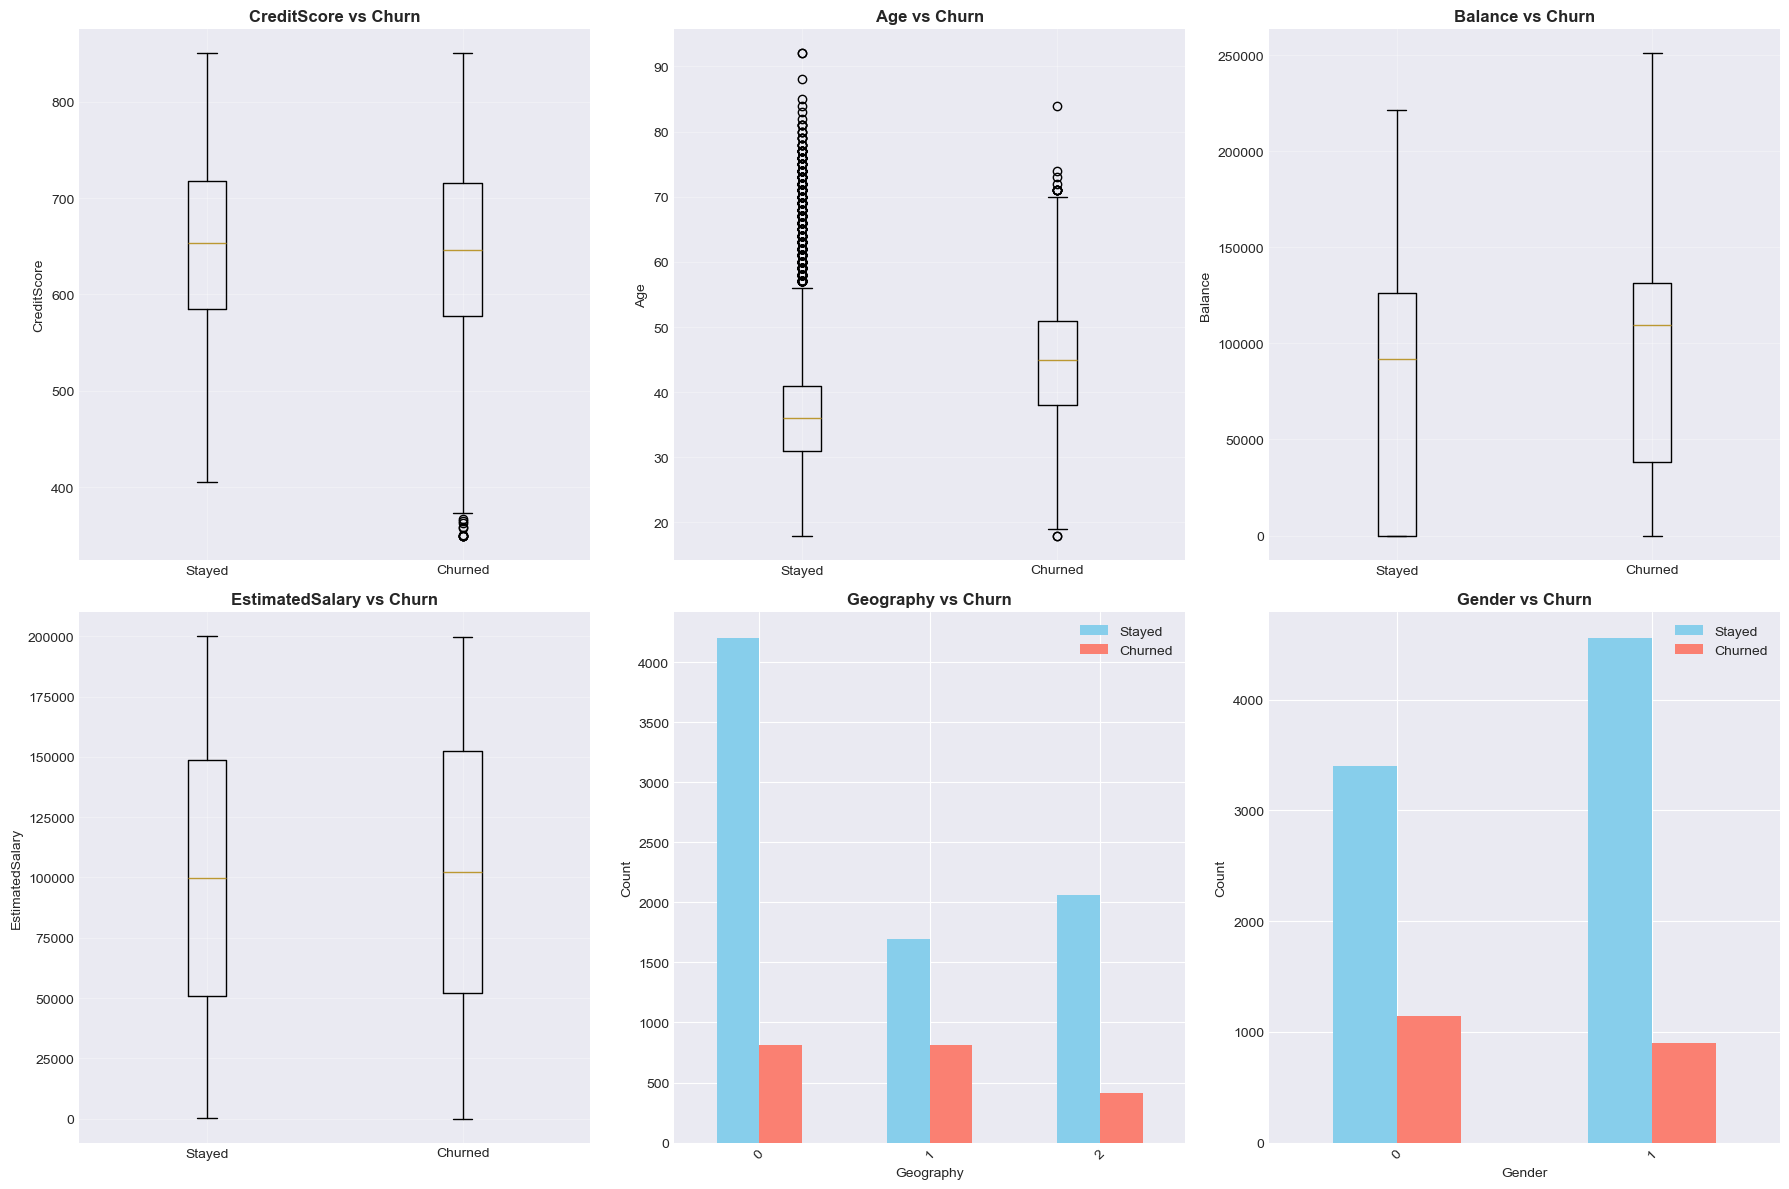

In [5]:
# VISUALIZE FEATURE DISTRIBUTIONS BY CLASS

print("=" * 70)
print("FEATURE DISTRIBUTION BY CHURN STATUS")
print("=" * 70)

# Create a DataFrame with encoded features and target
df_encoded = X_encoded.copy()
df_encoded['Exited'] = y.values

# Select key features to visualize
key_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Geography', 'Gender']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(key_features[:6]):
    if feature in ['Geography', 'Gender']:  # Categorical features
        # Create countplot for categorical features
        churn_counts = df_encoded.groupby([feature, 'Exited']).size().unstack()
        churn_counts.plot(kind='bar', ax=axes[idx], color=['skyblue', 'salmon'])
        axes[idx].set_title(f'{feature} vs Churn', fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Count')
        axes[idx].legend(['Stayed', 'Churned'])
        axes[idx].tick_params(axis='x', rotation=45)
    else:  # Numerical features
        # Create boxplot for numerical features
        data_to_plot = [df_encoded[df_encoded['Exited'] == 0][feature],
                       df_encoded[df_encoded['Exited'] == 1][feature]]
        axes[idx].boxplot(data_to_plot, labels=['Stayed', 'Churned'])
        axes[idx].set_title(f'{feature} vs Churn', fontweight='bold')
        axes[idx].set_ylabel(feature)
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("saved_images/feature_distribution_by_churn.png", dpi=300, bbox_inches='tight')
plt.show()

### Boxplot

1. **Credit Score vs. Churn**: Customers who stayed appear to have a slightly higher credit score than those who churned, suggesting creditworthiness might influence loyalty.

2. **Age vs. Churn**: The age of customers who stayed and those who churned seems very similar, indicating age itself is likely not a key factor in churn.

3. **Balance vs. Churn**: Customers who churned have a noticeably higher average account balance than those who stayed, meaning customers with more money saved may be more likely to leave.

### SPLIT DATA INTO TRAIN AND TEST SETS

In [11]:
X_encoded.drop("AgeGroup", axis = 1,  inplace=True)
X_encoded.head()



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [12]:
print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

# Split the data (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original dataset shape: {X_encoded.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

print("\nClass distribution in training set:")
train_class_dist = y_train.value_counts(normalize=True) * 100
print(f"Stayed (0): {train_class_dist[0]:.2f}%")
print(f"Churned (1): {train_class_dist[1]:.2f}%")

print("\nClass distribution in test set:")
test_class_dist = y_test.value_counts(normalize=True) * 100
print(f"Stayed (0): {test_class_dist[0]:.2f}%")
print(f"Churned (1): {test_class_dist[1]:.2f}%")

TRAIN-TEST SPLIT
Original dataset shape: (10000, 10)
Training set shape: (8000, 10)
Test set shape: (2000, 10)

Class distribution in training set:
Stayed (0): 79.62%
Churned (1): 20.38%

Class distribution in test set:
Stayed (0): 79.65%
Churned (1): 20.35%


### APPLY SMOTE FOR CLASS IMBALANCE HANDLING

In [13]:
print("\n\n"+"=" * 70)
print("APPLYING SMOTE (Synthetic Minority Over-sampling Technique)")
print("=" * 70)

# apply SMOTE to the training data only
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Training set shape: {X_train.shape}")
print(f"After SMOTE - Training set shape: {X_train_smote.shape}")



print("\nClass distribution before SMOTE (training set):")
before_smote_dist = y_train.value_counts()
print(f"Stayed (0): {before_smote_dist[0]}")
print(f"Churned (1): {before_smote_dist[1]}")

print("=" * 70)
print(f"Imbalance ratio: {before_smote_dist[0]/before_smote_dist[1]:.2f}:1")
print("=" * 70)

print("\nClass distribution after SMOTE (training set):")
after_smote_dist = y_train_smote.value_counts()
print(f"Stayed (0): {after_smote_dist[0]}")
print(f"Churned (1): {after_smote_dist[1]}")

print("=" * 70)
print(f"Imbalance ratio: {after_smote_dist[0]/after_smote_dist[1]:.2f}:1 [Balanced]")
print("=" * 70)



APPLYING SMOTE (Synthetic Minority Over-sampling Technique)
Before SMOTE - Training set shape: (8000, 10)
After SMOTE - Training set shape: (12740, 10)

Class distribution before SMOTE (training set):
Stayed (0): 6370
Churned (1): 1630
Imbalance ratio: 3.91:1

Class distribution after SMOTE (training set):
Stayed (0): 6370
Churned (1): 6370
Imbalance ratio: 1.00:1 [Balanced]


### VISUALIZE SMOTE RESULTS

VISUALIZING SMOTE RESULTS


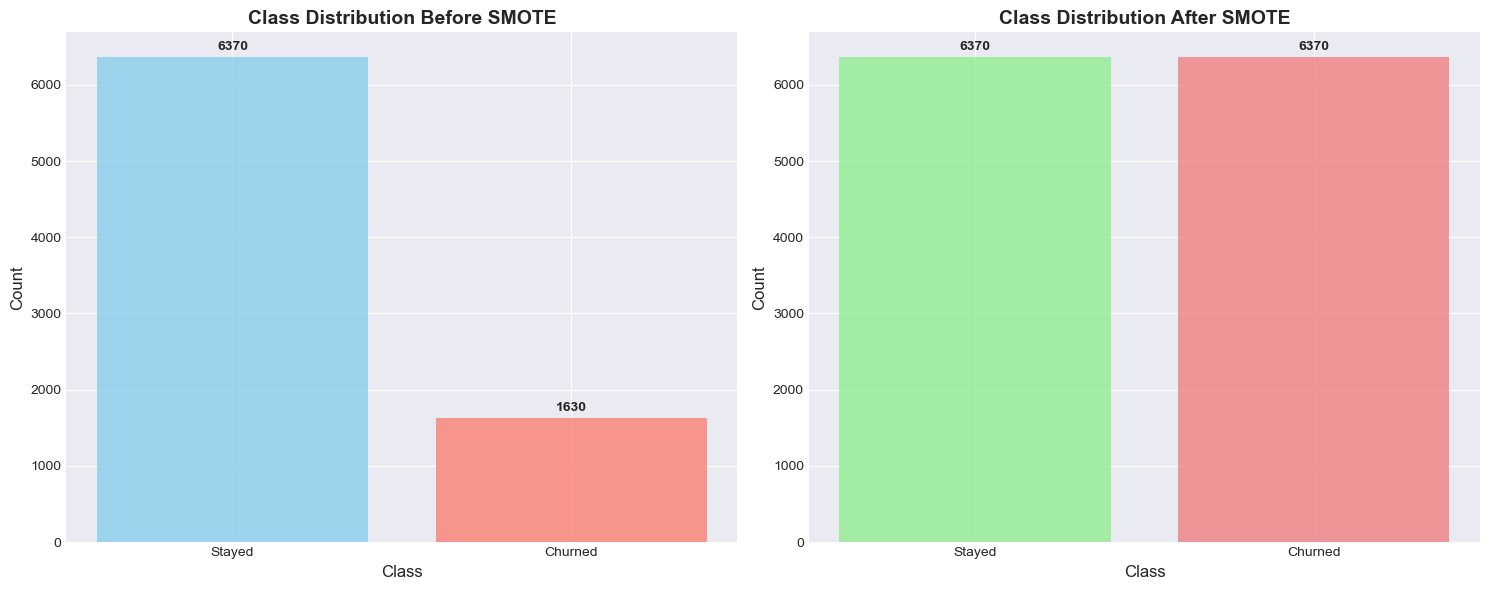

In [14]:


print("=" * 70)
print("VISUALIZING SMOTE RESULTS")
print("=" * 70)

# Visualize the effect of SMOTE
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Before SMOTE
axes[0].bar(['Stayed', 'Churned'], before_smote_dist.values, 
            color=['skyblue', 'salmon'], alpha=0.8)
axes[0].set_title('Class Distribution Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(before_smote_dist.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# After SMOTE
axes[1].bar(['Stayed', 'Churned'], after_smote_dist.values, 
            color=['lightgreen', 'lightcoral'], alpha=0.8)
axes[1].set_title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
for i, v in enumerate(after_smote_dist.values):
    axes[1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("saved_images/smote_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### FEATURE SCALING

In [16]:


print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

# Scale the features (important for many ML algorithms)
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

# Convert back to DataFrame for better visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

print("\nSummary statistics of scaled training data:")
X_train_scaled_df.describe().loc[['mean', 'std', 'min', 'max']]

FEATURE SCALING
Scaled training set shape: (12740, 10)
Scaled test set shape: (2000, 10)

Summary statistics of scaled training data:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
mean,-1.048525e-16,-8.923614e-18,1.784723e-17,2.498612e-16,1.204688e-16,-2.677084e-17,1.784723e-17,-3.569445e-17,0.000000,-3.692145e-16
std,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039,1.000039e+00
min,-3.264944e+00,-9.029241e-01,-8.519504e-01,-2.289808e+00,-1.782201e+00,-1.348935e+00,-7.282769e-01,-1.287004e+00,-0.765221,-1.752682e+00
max,2.194535e+00,1.744850e+00,1.173777e+00,5.092340e+00,1.888698e+00,2.564143e+00,4.569543e+00,7.769981e-01,1.306812,1.721832e+00


In [19]:
# X_train_scaled

### MODEL TRAINING AND EVALUATION

In [20]:
print("=" * 70)
print("MODEL TRAINING WITH SMOTE")
print("=" * 70)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Store results
results = {}
# model = LogisticRegression(random_state=42, max_iter=1000)
# Train and evaluate each model
for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")
    
    # Train model
    model.fit(X_train_scaled, y_train_smote)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Store results
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    
    # Classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

MODEL TRAINING WITH SMOTE

Training Logistic Regression...
Accuracy: 0.7305
Precision: 0.3962
Recall: 0.6192
F1-Score: 0.4832
ROC-AUC: 0.7435
Average Precision: 0.4514

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.89      0.76      0.82      1593
     Churned       0.40      0.62      0.48       407

    accuracy                           0.73      2000
   macro avg       0.64      0.69      0.65      2000
weighted avg       0.79      0.73      0.75      2000


Training Random Forest...
Accuracy: 0.8120
Precision: 0.5312
Recall: 0.6486
F1-Score: 0.5841
ROC-AUC: 0.8406
Average Precision: 0.5976

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Stayed       0.90      0.85      0.88      1593
     Churned       0.53      0.65      0.58       407

    accuracy                           0.81      2000
   macro avg       0.72      0.75      0.73      2000
weighte

### CONFUSION MATRICES WITH PERCENTAGES

CONFUSION MATRICES (WITH PERCENTAGES)


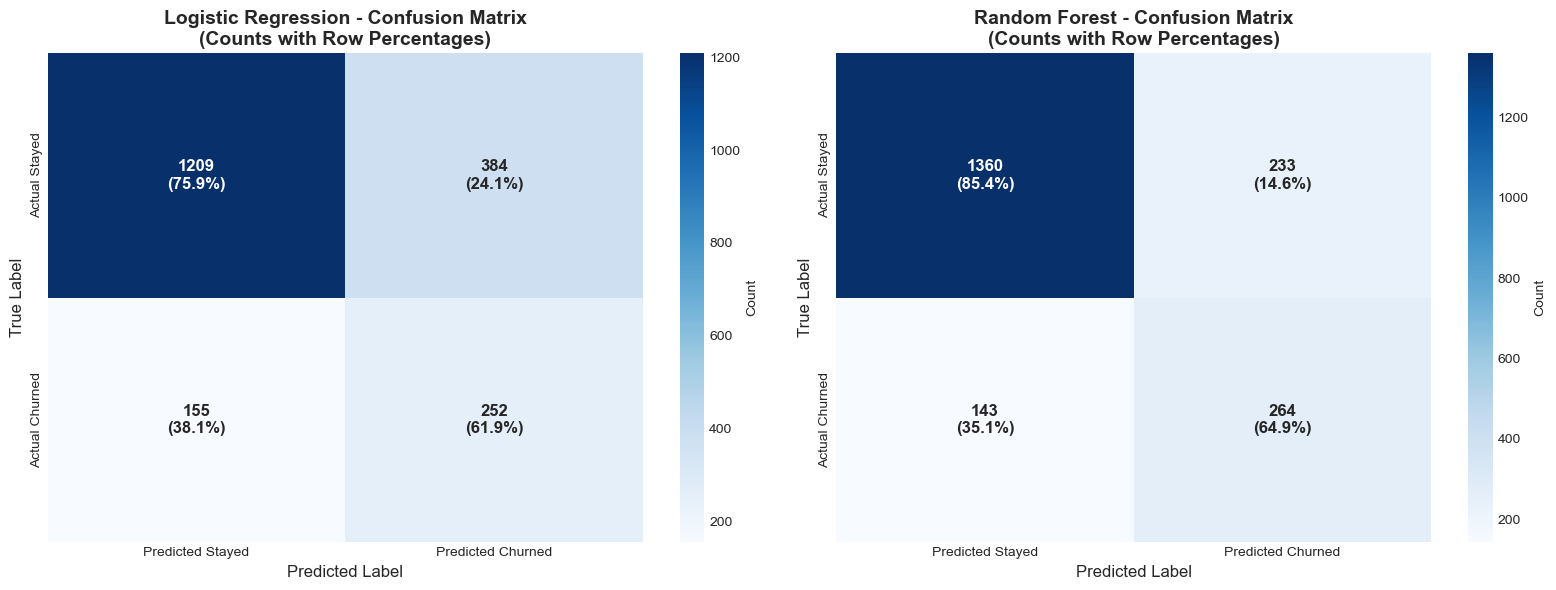

In [21]:


print("=" * 70)
print("CONFUSION MATRICES (WITH PERCENTAGES)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, result) in enumerate(results.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create annotations with both counts and percentages
    annotations = []
    for i in range(cm.shape[0]):
        row_annotations = []
        for j in range(cm.shape[1]):
            count = cm[i, j]
            percent = cm_percent[i, j]
            row_annotations.append(f"{count}\n({percent:.1f}%)")
        annotations.append(row_annotations)
    
    # Create heatmap
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Predicted Stayed', 'Predicted Churned'],
                yticklabels=['Actual Stayed', 'Actual Churned'],
                cbar_kws={'label': 'Count'},
                annot_kws={"size": 12, "weight": "bold"})
    
    ax.set_title(f'{model_name} - Confusion Matrix\n(Counts with Row Percentages)', 
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig("saved_images/confusion_matrices_smote_percentages.png", dpi=300, bbox_inches='tight')
plt.show()

## ROC CURVES AND PRECISION-RECALL CURVES

ROC CURVES AND PRECISION-RECALL CURVES


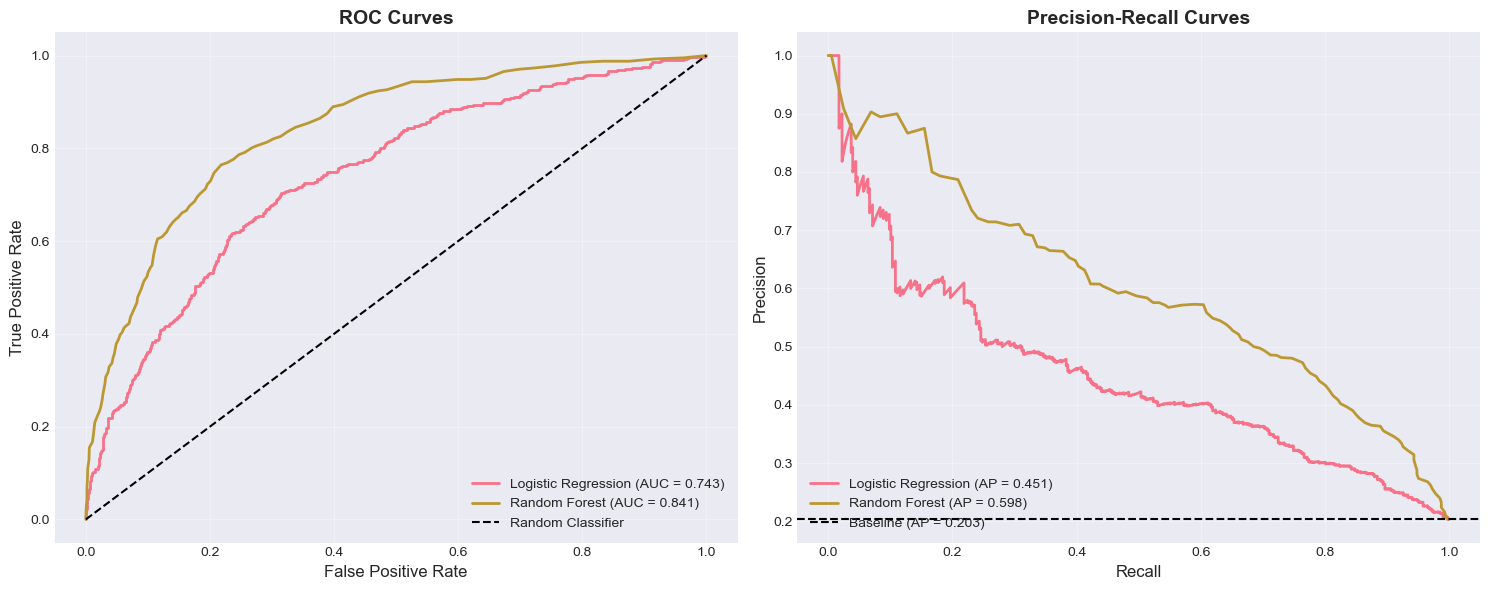

In [22]:


print("=" * 70)
print("ROC CURVES AND PRECISION-RECALL CURVES")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
ax1 = axes[0]
for model_name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = result['roc_auc']
    ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Precision-Recall Curves
ax2 = axes[1]
for model_name, result in results.items():
    precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
    avg_precision = result['avg_precision']
    ax2.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.3f})', linewidth=2)

# Add baseline (percentage of positive class)
baseline = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline (AP = {baseline:.3f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("saved_images/roc_pr_curves_smote.png", dpi=300, bbox_inches='tight')
plt.show()

## FEATURE IMPORTANCE ANALYSIS (for Random Forest)

FEATURE IMPORTANCE ANALYSIS
Top 10 Most Important Features:
           Feature  Importance
3              Age      0.2222
5          Balance      0.1254
9  EstimatedSalary      0.1240
0      CreditScore      0.1107
8   IsActiveMember      0.1083
6    NumOfProducts      0.1071
4           Tenure      0.0711
2           Gender      0.0595
1        Geography      0.0516
7        HasCrCard      0.0202


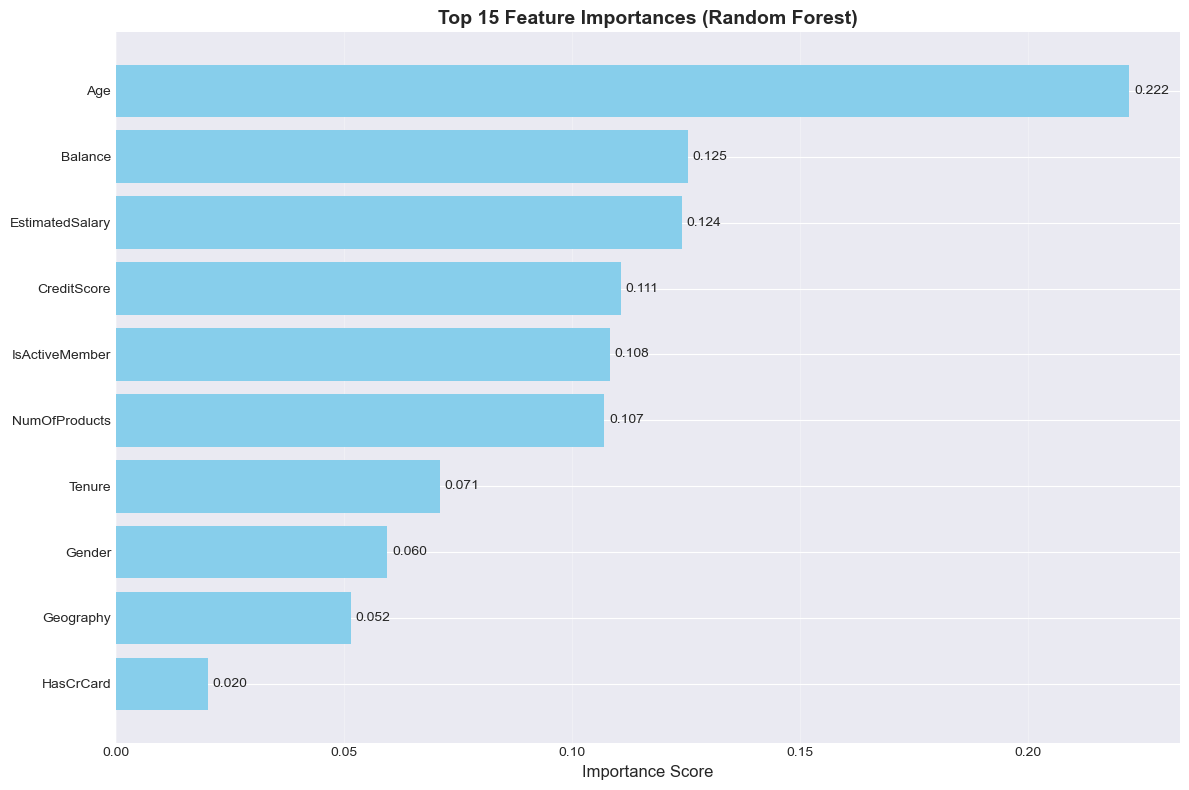

In [23]:


print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get Random Forest model
rf_model = results['Random Forest']['model']

# Get feature importances
feature_importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# Create DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10).round(4))

# Visualize feature importances
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], 
                color='skyblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.savefig("saved_images/feature_importance_smote.png", dpi=300, bbox_inches='tight')
plt.show()

## HYPERPARAMETER TUNING WITH CROSS-VALIDATION

In [25]:
# HYPERPARAMETER TUNING WITH CROSS-VALIDATION
print("=" * 70)
print("HYPERPARAMETER TUNING WITH CROSS-VALIDATION")
print("=" * 70)

# Create a pipeline with SMOTE and Random Forest
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define parameter grid

# TOO MANY FITS
# param_grid = {
#     'classifier__n_estimators': [100, 200, 300],
#     'classifier__max_depth': [10, 20, 30, None],
#     'classifier__min_samples_split': [2, 5, 10],
#     'classifier__min_samples_leaf': [1, 2, 4]
# }


# REDUCE FITS: FROM 516 TO 120 fits

param_grid = {
    'classifier__n_estimators': [100, 200],        # Reduced from 3 to 2
    'classifier__max_depth': [10, 20, None],       # Reduced from 4 to 3
    'classifier__min_samples_split': [2, 5],       # Reduced from 3 to 2
    'classifier__min_samples_leaf': [1, 2]         # Reduced from 3 to 2
}

# Use stratified k-fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Performing grid search with cross-validation...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics for tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\nTuned Model Performance on Test Set:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_tuned:.4f}")

print("Finish!")

HYPERPARAMETER TUNING WITH CROSS-VALIDATION
Performing grid search with cross-validation...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best cross-validation F1 score: 0.5822

Tuned Model Performance on Test Set:
Accuracy: 0.8145
Precision: 0.5364
Recall: 0.6511
F1-Score: 0.5882
ROC-AUC: 0.8442
Finish!


COMPREHENSIVE MODEL COMPARISON

Training Baseline Model (without SMOTE)...

Final Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Baseline (No SMOTE)    0.8645     0.7857  0.4595    0.5798   0.8469
1  SMOTE Random Forest    0.8120     0.5312  0.6486    0.5841   0.8406
2       Tuned SMOTE RF    0.8145     0.5364  0.6511    0.5882   0.8442


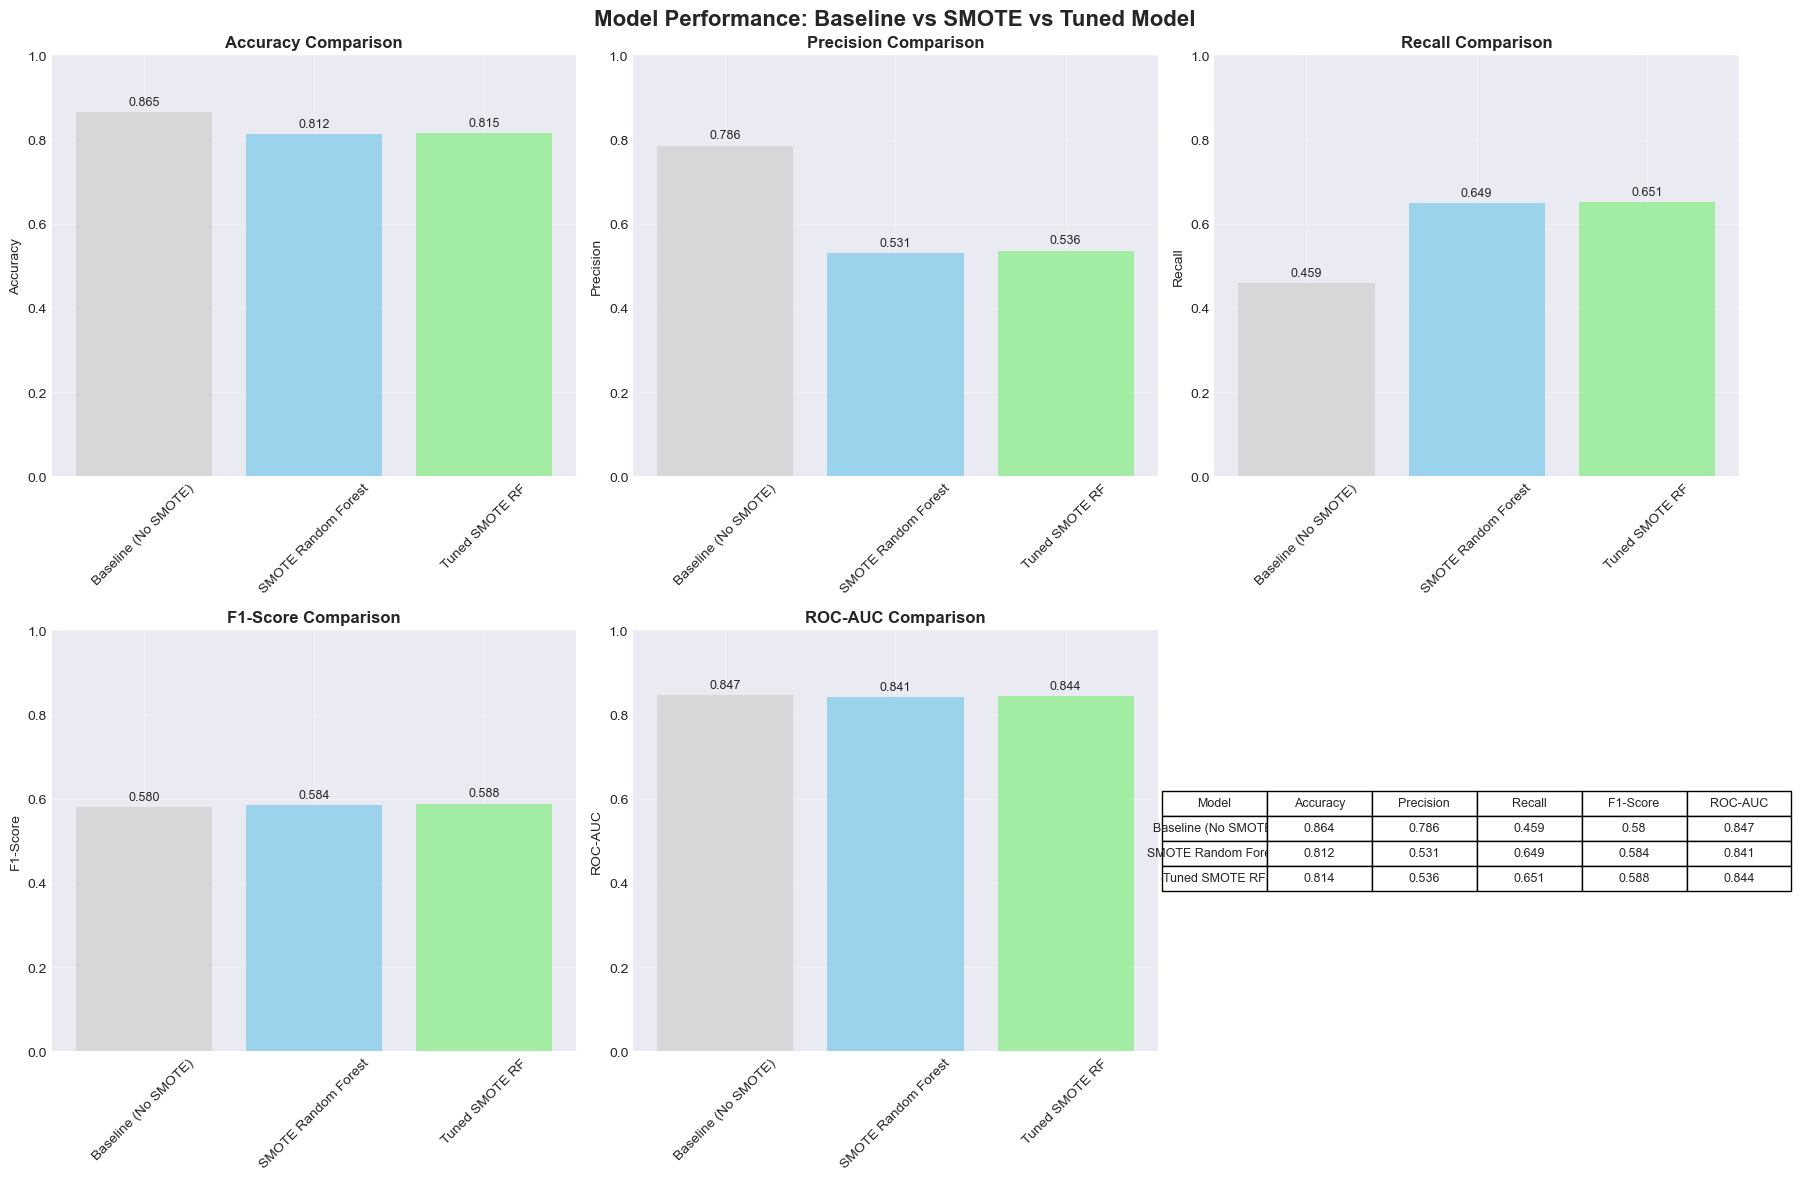

In [26]:
# COMPARE BASELINE VS SMOTE VS TUNED MODEL

print("=" * 70)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 70)

# Train a baseline model without SMOTE for comparison
print("\nTraining Baseline Model (without SMOTE)...")

# Scale features for baseline
scaler_baseline = StandardScaler()
X_train_baseline_scaled = scaler_baseline.fit_transform(X_train)
X_test_baseline_scaled = scaler_baseline.transform(X_test)

# Train Random Forest without SMOTE
rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
rf_baseline.fit(X_train_baseline_scaled, y_train)

# Predictions
y_pred_baseline = rf_baseline.predict(X_test_baseline_scaled)
y_pred_proba_baseline = rf_baseline.predict_proba(X_test_baseline_scaled)[:, 1]

# Calculate metrics
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)

# Create comparison DataFrame
final_comparison = pd.DataFrame({
    'Model': ['Baseline (No SMOTE)', 'SMOTE Random Forest', 'Tuned SMOTE RF'],
    'Accuracy': [accuracy_baseline, results['Random Forest']['accuracy'], accuracy_tuned],
    'Precision': [precision_baseline, results['Random Forest']['precision'], precision_tuned],
    'Recall': [recall_baseline, results['Random Forest']['recall'], recall_tuned],
    'F1-Score': [f1_baseline, results['Random Forest']['f1_score'], f1_tuned],
    'ROC-AUC': [roc_auc_baseline, results['Random Forest']['roc_auc'], roc_auc_tuned]
})

print("\nFinal Model Comparison:")
print(final_comparison.round(4))

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    models_list = final_comparison['Model'].tolist()
    values = final_comparison[metric].tolist()
    
    colors = ['lightgray', 'skyblue', 'lightgreen']
    bars = ax.bar(models_list, values, color=colors, alpha=0.8)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# Add a summary table in the last subplot
ax = axes[5]
ax.axis('tight')
ax.axis('off')
table_data = final_comparison.round(3).values
table = ax.table(cellText=table_data,
                 colLabels=final_comparison.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.suptitle('Model Performance: Baseline vs SMOTE vs Tuned Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("saved_images/final_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## SAVE EVERYTHING IN ONE FILE

In [34]:
print("=" * 70)
print("SAVING COMPLETE MODEL BUNDLE")
print("=" * 70)

# Create a complete bundle with everything needed for predictions
model_bundle = {
    # The complete pipeline (SMOTE + Scaler + Classifier)
    'pipeline': best_model,
    
    # Label encoders for categorical variables (CRITICAL!)
    'label_encoders': label_encoders,
    
    # Feature names in the exact order used during training
    'feature_names': X_train.columns.tolist(),
    
    # Categorical column names
    'categorical_cols': categorical_cols,
    
    # Performance metrics (optional, for reference)
    'performance': {
        'test_set': {
            'accuracy': float(accuracy_tuned),
            'precision': float(precision_tuned),
            'recall': float(recall_tuned),
            'f1_score': float(f1_tuned),
            'roc_auc': float(roc_auc_tuned)
        }
    },
    
    # Metadata
    'metadata': {
        'model_type': 'RandomForest with SMOTE',
        'created_at': pd.Timestamp.now().isoformat(),
        'target_column': 'Exited',
        'features_count': X_train.shape[1]
    }
}

# Save everything in ONE file
joblib.dump(model_bundle, 'saved_models/complete_model_bundle.pkl')
print("Complete model bundle saved as 'saved_models/complete_model_bundle.pkl'")
print("Includes: Pipeline + Label Encoders + Feature names + metadata")

SAVING COMPLETE MODEL BUNDLE
Complete model bundle saved as 'saved_models/complete_model_bundle.pkl'
Includes: Pipeline + Label Encoders + Feature names + metadata


In [40]:
# test_churn_data = pd.read_csv("test_data/test_churn_data.csv")
# columns_to_drop = ['Exited', 'AgeGroup']
# test_churn_data.drop(columns_to_drop, axis = 1, inplace = True)
# test_churn_data.to_csv('test_data/test_churn_data.csv')
# test_churn_data.head()

In [41]:
# SIMPLE VERSION - DROP NON-FEATURE COLUMNS
print("=" * 50)
print("MAKING PREDICTIONS")
print("=" * 50)



# LOAD MODEL
model_bundle = joblib.load('saved_models/complete_model_bundle.pkl')
pipeline = model_bundle['pipeline']
label_encoders = model_bundle['label_encoders']



# LOAD DATA
test_data = pd.read_csv('test_data/test_churn_data.csv')

# DROP COLUMNS THAT AREN'T FEATURES
columns_to_drop = ['CustomerId', 'RowNumber', 'Surname']
X_new = test_data.drop(columns=[col for col in columns_to_drop if col in test_data.columns])

# ENCODE CATEGORICAL VARIABLES USING SAVED ENCODERS
for col, encoder in label_encoders.items():
    if col in X_new.columns:
        # Handle unseen categories by setting them to -1 or most frequent
        X_new[col] = X_new[col].apply(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1)


# ENSURE COLUMN ORDER MATCHES TRAINING
X_new = X_new[model_bundle['feature_names']]

# MAKE and SAVE PREDICTIONS
predictions = pipeline.predict(X_new)
probabilities = pipeline.predict_proba(X_new)

test_data['prediction'] = predictions
test_data['prediction_probability'] = probabilities[:, 1]
test_data.to_csv('test_data/test_data_predictions.csv', index=False)



print(f"Predictions saved to test_data/test_data_predictions.csv")
print(f"Total: {len(predictions)} samples")
print(f"Class 0: {sum(predictions == 0)}, Class 1: {sum(predictions == 1)}")

MAKING PREDICTIONS
Predictions saved to test_data/test_data_predictions.csv
Total: 50 samples
Class 0: 39, Class 1: 11


In [20]:
predicted  = pd.read_csv("test_data/test_data_predictions.csv")
predicted.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,prediction,prediction_probability
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.623180
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.257333
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.964762
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.202179
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.071667
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,0.567272
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0.022000
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,0.904381
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0.267079
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0.064976
